# Introduction to the Digital Twin, Part 3:  Customizing a scenario.

In the previous notebooks, we looked at simple 2-aircraft scenarios on the I- and Y- sectors, and an example scenario in the Springfield airspace.   In all these cases we used the "out-of-the-box" configuration - creating the Simulator just by passing the category and name of the scenario.

In this notebook, we will instantiate a "scenario manager", and use this to generate a Simulator.   This way we have full control over the parameters of the scenario manager, such as the number of aircraft to be generated.

In [1]:
# Visualisation-related imports 

import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import SVG, Image

%matplotlib inline

### Generating an Airspace and Routes

We will again use a simple artificial airspace - this time the "X" sector, which is the next step up in complexity from the "Y" sector.   Since there are four ways in our out of this sector, there is a defined set of "Routes" (i.e. the possible sequences of fixes that an aircraft might follow through the sector).

We will use the "AirspaceLoader" to create the X-sector airspace, as well as the allowed Routes across it, and the sector name (that will be used in creating a ScenarioManager).

In [2]:
from bluebird_dt.airspace_generator.airspace_loader import AirspaceLoader
airspace, routes, sector_name = AirspaceLoader.load("X-Sector")

Let's visualize this airspace:

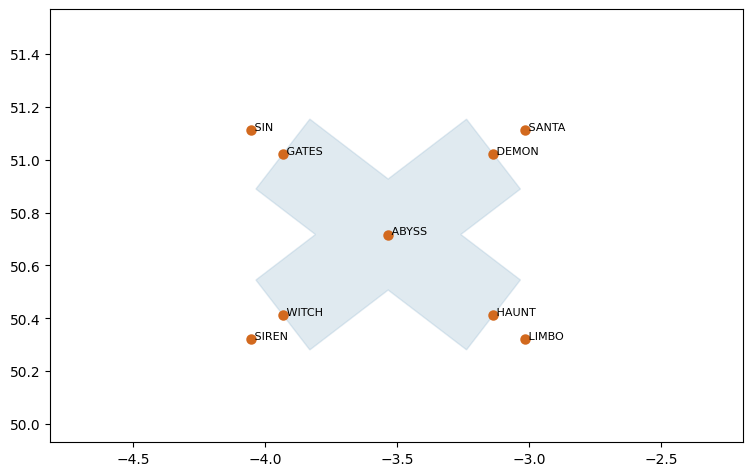

In [3]:
from bluebird_dt.core import Pos2D
from bluebird_dt.render import Radar

view_centre = Pos2D.from_str("50.75N 3.5W")
view_width = 100.0  # [nmi] about 1 degree of longitude
aspect_ratio = 1.6

radar = Radar(view_centre, view_width, aspect_ratio)
radar.draw_airspace(airspace)

In [4]:
# print some of the possible Routes through the airspace
print([r.filed for r in routes[:4]])

[['SIREN', 'WITCH', 'ABYSS', 'DEMON', 'SANTA'], ['SIREN', 'WITCH', 'ABYSS', 'GATES', 'SIN'], ['SIREN', 'WITCH', 'ABYSS', 'HAUNT', 'LIMBO'], ['LIMBO', 'HAUNT', 'ABYSS', 'GATES', 'SIN']]


Now we can use the airway and routes to instantiate the "Custom" scenario manager

In [5]:
from bluebird_dt.scenario_manager.custom import Custom
sm = Custom(airspace=airspace, routes=routes, num_aircraft=4)

The in-line documentation for the scenario manager should help us see what else we can configure:

In [6]:
help(sm)

Help on Custom in module bluebird_dt.scenario_manager.custom object:

class Custom(bluebird_dt.scenario_manager.scenario_manager.ScenarioManager, typing.Generic)
 |  Custom(
 |      num_aircraft: int,
 |      airspace: bluebird_dt.core.airspace.Airspace,
 |      routes: list[bluebird_dt.core.route.Route],
 |      sector_name: str | None = None,
 |      balance: tuple[float, float, float] | None = None,
 |      speed_range: tuple[float, float] | None = None,
 |      time_entry_gap: float = 5,
 |      random_seed: int | None = None,
 |      aircraft_on_route: bool = False,
 |      lateral_offset: tuple[float, float] | None = None,
 |      start_time: int = 0,
 |      vertical_buffer_distance: float | int = 500,
 |      lateral_buffer_distance: float | int = 20,
 |      typeof_environment_manager: type[~TEnvironmentManager] = <class 'bluebird_dt.manager.environment_manager.EnvironmentManager'>,
 |      typeof_event_handler: type[~TEventHandler] = <class 'bluebird_dt.events.event_handler.E

We have already provided the airspace, routes, and number of aircraft.   Lets specify the speed range (in knots), and set the "balance" such that all the aircraft will be "climbers" (i.e. will exit the sector at a higher altitude than they enter it).

In [7]:
sm.speed_range = [500,600] # quite fast!!
sm.balance = [1,0,0]

We can now use the scenario manager to create a Simulator instance.

In [8]:
sim = sm.to_simulator()

### Visualising the scenario

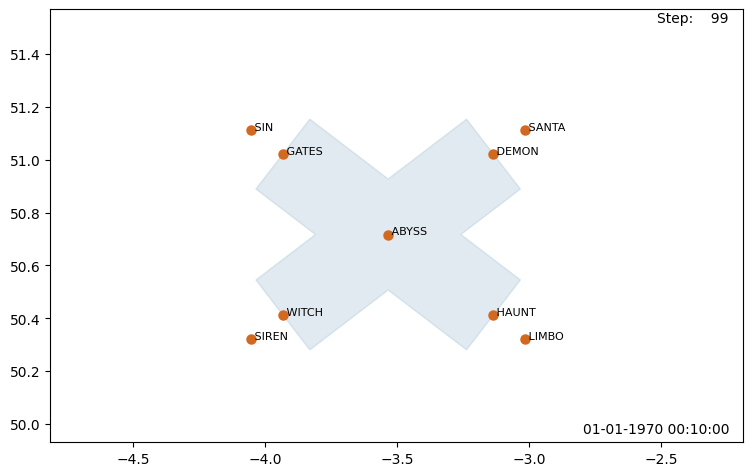

In [9]:
import IPython.display

# the radar is re-instantiated. no need to clear the screen.
radar = Radar(view_centre, view_width, aspect_ratio) # re-introduce the spines/axes

for _ in range(100):
    sim.evolve(6.0)
    figure, ax = radar.draw(sim.manager.environment)

    IPython.display.display(figure) # or IPython.display.display(plt.gcf())
    IPython.display.clear_output(wait=True)

## Fully customising the scenario

In the example above, we specified the number of aircraft, the speed range, and the balance of "climbers"/"descenders"/"overfliers", but the aircraft were still generated randomly (which is likely what we would want for training an AI agent).   

However, the Custom scenario manager also allows us to fully specify a scenario, adding each aircraft with its precise parameters and entry time.

In [12]:
# create a Custom scenario manager with no starting aircraft
sm = Custom(airspace=airspace, routes=routes, num_aircraft=0, start_time=0.)


In [13]:
# choose a callsign for our first aircraft
callsign="CUSTOM-00"
# choose the first of the allowed routes, which starts at the bottom left (goes "SIREN"->"WITCH"->...)
route = routes[0]
# start at the location of "WITCH", at flight level 250
start_pos = airspace.fixes.places["WITCH"].pos3d(fl=250)
# heading should be from SW to NE, so around 45 degrees
heading = 45.
# pick a sensible speed, say 400 knots
speed = 400.
# If the scenario starts at time 0, lets spawn this aircraft 10 seconds later
t=10.
# For the "Coordinations" (agreements on how an aircraft enters or leaves the sector), pick some sensible flight levels
entry_fl, exit_fl = 250., 300.
# Should the aircraft follow its route (True) or fly at constant heading (False)?
on_route=True

# Now we call the Custom scenario manager's `add_aircraft_with_coordinations` method:
sm.add_aircraft_with_coordinations(
    aircraft_start_time=t,
    callsign=callsign,
    pos=start_pos,
    heading=heading,
    speed=speed,
    route=route,
    entry_fl=entry_fl,
    exit_fl=exit_fl,
    on_route=on_route
)

Let's add a second aircraft.  We pass in the EventHandler that we got back from the first call to the `add_aircraft_with_coordinations` method.

In [14]:
# Use the fourth route in the list of routes, that goes from bottom right to top left (starting "LIMBO"->"HAUNT").
route = routes[3]
start_pos = airspace.fixes.places["LIMBO"].pos3d(fl=260)

sm.add_aircraft_with_coordinations(
    aircraft_start_time=t+10, # start 10s after the other aircraft
    callsign="CUSTOM-01",
    pos=start_pos,
    heading=315, # SE to NW
    speed=speed,
    route=route,
    entry_fl=entry_fl,
    exit_fl=exit_fl,
    on_route=on_route
)

In [15]:
# Create a Simulator from this Scenario Manager
sim = sm.to_simulator()

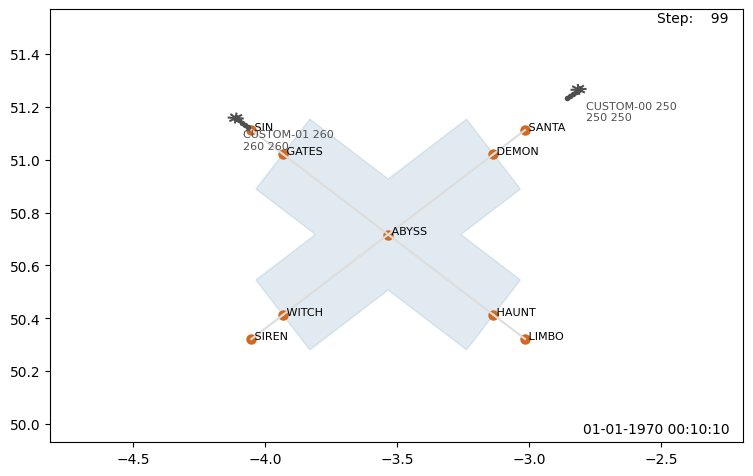

In [16]:
# Visualize this scenario
radar = Radar(view_centre, view_width, aspect_ratio) # re-introduce the spines/axes

for _ in range(100):
    sim.evolve(6.0)
    figure, ax = radar.draw(sim.manager.environment)

    IPython.display.display(figure) # or IPython.display.display(plt.gcf())
    IPython.display.clear_output(wait=True)

### The "Infinite" scenario manager

Up to now, the scenarios we have looked at have had a finite (and generally small) number of aircraft.   There is another scenario manager in bluebird_dt that is able to add an unlimited number of aircraft, spawning randomly at the edge of the sector.   Let's instantiate that now, looking at the "Xplus", which is a slightly asymmetric variation of the X-sector, with extra available routes.

In [17]:
# generate airspace and routes for xplus-sector
airspace, routes, sector_name = AirspaceLoader.load("Xplus-Sector")
# import and instantiate the Infinite scenario manager
from bluebird_dt.scenario_manager.infinite import Infinite
# instantiate the scenario manager
sm = Infinite(airspace=airspace, routes=routes)

Again, we can look at the source code, or use `help` to see what parameters are available to configure the scenario manager:

In [18]:
help(sm)

Help on Infinite in module bluebird_dt.scenario_manager.infinite object:

class Infinite(bluebird_dt.scenario_manager.scenario_manager.ScenarioManager, typing.Generic)
 |  Infinite(
 |      airspace: bluebird_dt.core.airspace.Airspace,
 |      routes: list[bluebird_dt.core.route.Route],
 |      sector_name: str | None = None,
 |      initial_spawn_rate: float = 0.01,
 |      max_spawn_rate: float = 0.1,
 |      spawn_rate_increment: float = 0.0,
 |      spawn_rate_increase_interval: float = 0.0,
 |      spawn_distance_threshold: float = 10,
 |      spawn_distance_behind_fix: float = 10.0,
 |      total_time_seconds: float | None = None,
 |      random_seed: int | None = None,
 |      automatic_outcomm: bool = True,
 |      num_starter_aircraft: int = 2,
 |      speed_range: tuple[float, float] | None = None,
 |      aircraft_on_route: bool = False,
 |      typeof_environment_manager: type[~TEnvironmentManager] = <class 'bluebird_dt.manager.environment_manager.EnvironmentManager'>,
 |  

By default, aircraft will spawn stochastically at a constant average frequency.   It is possible however to ramp up the frequency by `spawn_rate_increment` every `spawn_rate_increate_interval` seconds, until it reaches `max_spawn_rate`.    It is also possible to set the `random_seed`, if we want to reproduce the same set of aircraft in different runs.

Lets set the number of starting aircraft to 2, the initial spawn rate to 0.01 (i.e. on average one aircraft will spawn every 100 seconds), set the `spawn_rate_increment` to zero so the spawn frequency remains constant, and specify the random seed.

In [19]:
sm.num_starter_aircraft=2
sm.initial_spawn_rate = 0.01
sm.spawn_rate_increment = 0.
sm.random_seed = 1234
# instantiate the Simulator
sim = sm.to_simulator()

And let's run the scenario for 200 steps (though note that it could continue indefinitely!)

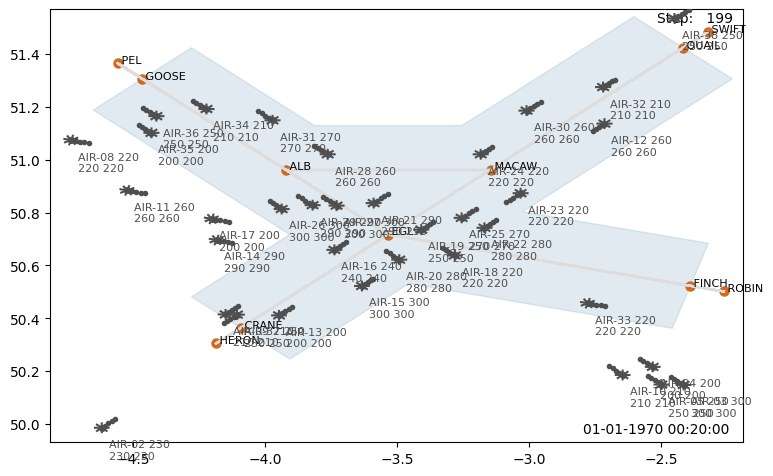

In [20]:
import IPython.display

# the radar is re-instantiated. no need to clear the screen.
radar = Radar(view_centre, view_width, aspect_ratio) # re-introduce the spines/axes

for _ in range(200):
    sim.evolve(6.0)
    figure, ax = radar.draw(sim.manager.environment)

    IPython.display.display(figure) # or IPython.display.display(plt.gcf())
    IPython.display.clear_output(wait=True)

### Conclusions

In this notebook, we saw how to configure scenarios by constructing the scenario manager, and set its parameters.   We also looked at the "Infinite" scenario manager, and a couple of new sectors ("X" and "Xplus").

In the next notebook we will take another peek under the hood of the digital twin, and look at "Predictors" - how the simulation evolves aircraft from one timestep to the next. 